In [1]:
# ton dağılımını grafiksel olarak gösterir. her bir ton için pixel sayısını gösterir

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(371, 366, 3)


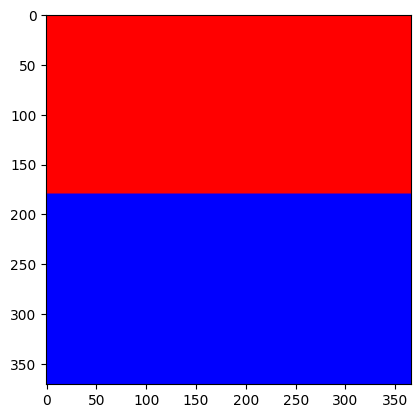

In [3]:
img = cv2.imread("red_blue.jpg")
img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(), plt.imshow(img_vis)

print(img.shape)

(256, 1)


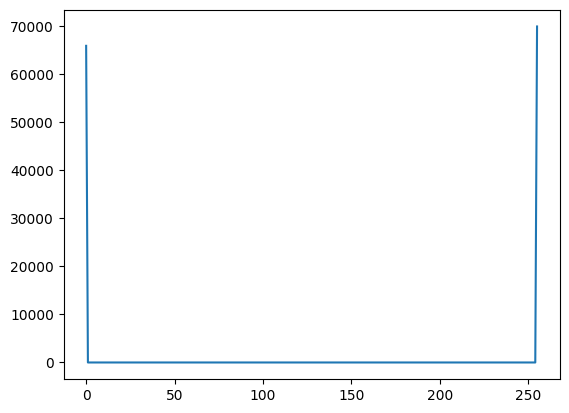

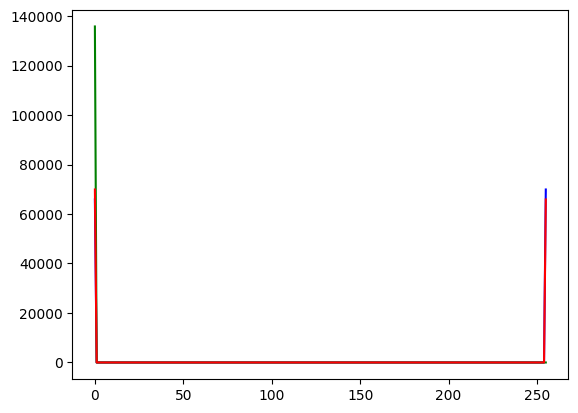

In [4]:
# channels=[0] grayscale demek. mask, resmin belli bir kısmını almakla ilgili
img_hist = cv2.calcHist([img], channels=[0], mask = None, histSize=[256], ranges=[0, 256])
print(img_hist.shape)
plt.figure(), plt.plot(img_hist)

color = ("b", "g", "r")
plt.figure()
for i, c in enumerate(color):
    hist = cv2.calcHist([img], channels=[i], mask = None, histSize=[256], ranges=[0, 256])
    plt.plot(hist, color = c)

In [5]:
# grafikte hangi renkten kaç pixel varsa gösteriyor, rgb için ayrı ayrı, bu yüzden shape*3 sonucu, toplam r g ve b değerlerinin sayısını verir.
"""
Matris Yapısı: Renkli bir görüntü aslında üç katmanlı bir matristir. Eğer resmin $1000 \times 1000$ boyutundaysa, elinde toplam $1.000.000$ piksel vardır.Kanal Başına Dağılım: Her bir pikselin içinde mutlaka bir R, bir G ve bir B değeri bulunur. Dolayısıyla:Kırmızı kanalında toplam $1.000.000$ tane değer sayılır.Yeşil kanalında toplam $1.000.000$ tane değer sayılır.Mavi kanalında toplam $1.000.000$ tane değer sayılır.
"""

'\nMatris Yapısı: Renkli bir görüntü aslında üç katmanlı bir matristir. Eğer resmin $1000 \times 1000$ boyutundaysa, elinde toplam $1.000.000$ piksel vardır.Kanal Başına Dağılım: Her bir pikselin içinde mutlaka bir R, bir G ve bir B değeri bulunur. Dolayısıyla:Kırmızı kanalında toplam $1.000.000$ tane değer sayılır.Yeşil kanalında toplam $1.000.000$ tane değer sayılır.Mavi kanalında toplam $1.000.000$ tane değer sayılır.\n'

(2448, 3264, 3)


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x1d84308d450>)

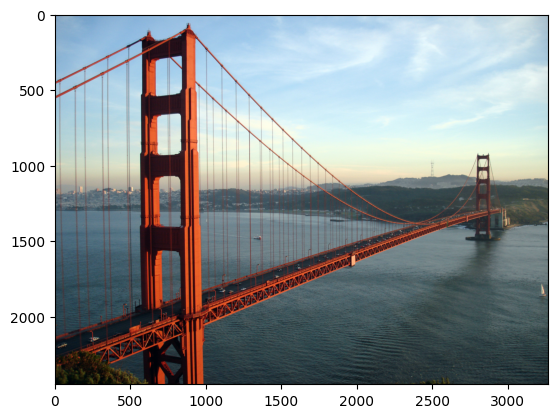

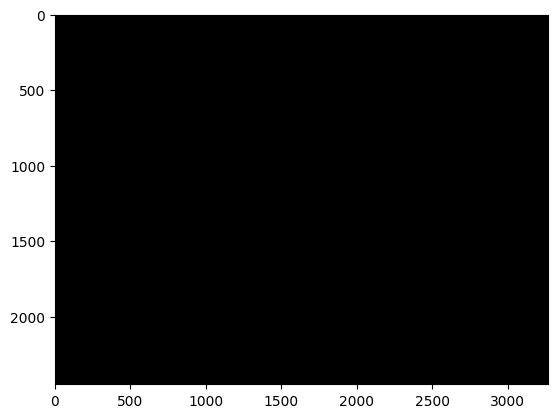

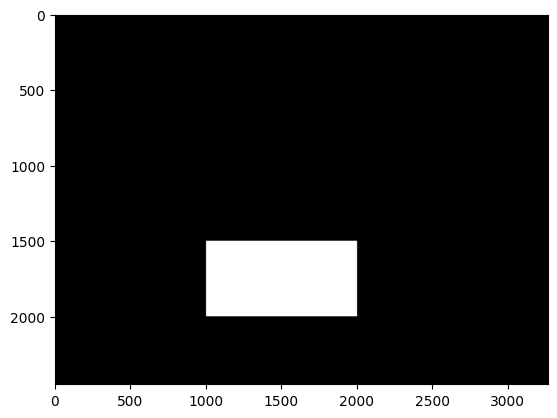

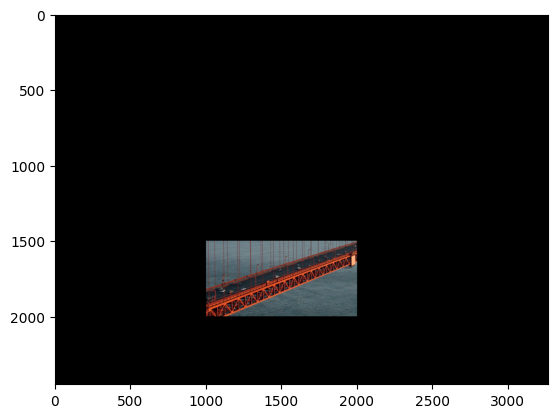

In [6]:
golden_gate = cv2.imread("goldenGate.jpg")
golden_gate_vis = cv2.cvtColor(golden_gate, cv2.COLOR_BGR2RGB)
plt.figure(), plt.imshow(golden_gate_vis)

print(golden_gate.shape)

mask = np.zeros(golden_gate.shape[:2], np.uint8)
plt.figure(), plt.imshow(mask, cmap="gray")

mask[1500:2000, 1000:2000] = 255
plt.figure(), plt.imshow(mask, cmap="gray")

masked_img_vis = cv2.bitwise_and(golden_gate_vis, golden_gate_vis, mask=mask)
plt.figure(), plt.imshow(masked_img_vis, cmap="gray")


(<Figure size 640x480 with 1 Axes>,
 [<matplotlib.lines.Line2D at 0x1d8433360d0>])

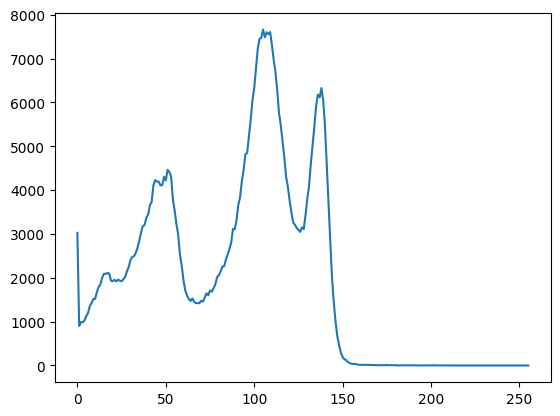

In [7]:
# draw histogram
masked_img = cv2.bitwise_and(golden_gate, golden_gate, mask=mask)
masked_img_hist = cv2.calcHist([golden_gate], channels=[0], mask = mask, histSize=[256], ranges=[0, 256])
plt.figure(), plt.plot(masked_img_hist)

In [8]:
# yorumlama: (yukarıdaki grafikte channel[0] dediğimiz için rgb de red e karşılık geliyor) bu grafil aslında tüm pixellerin red değerierindeki genlik değeri dağılımı
# 7500 küsür pixelin genlik değeri 105 miş, 6000 tane pixelin genlik değeri 137 imiş

(<Figure size 640x480 with 1 Axes>,
 [<matplotlib.lines.Line2D at 0x1d84d590b90>])

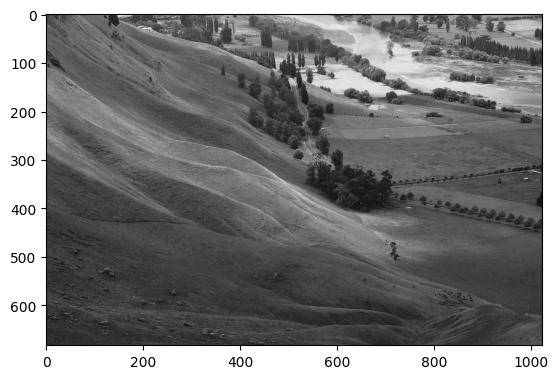

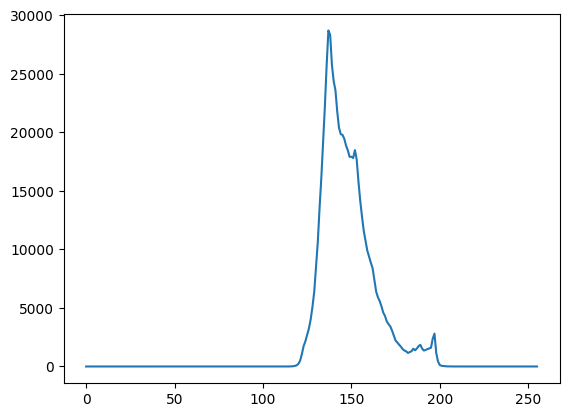

In [9]:
# histogram eşitleme -> kontrastı (karşıtlık) artırmak
# yükleyeceğimiz resimde renkler iç içe girdiği için pek anlaşılmıyor, o yüzden kontrastı artırıp detayları ortaya çıkarcaz
img = cv2.imread("hist_equ.jpg", 0)
plt.figure(), plt.imshow(img, cmap="gray")

img_hist = cv2.calcHist([img], channels=[0], mask = None, histSize=[256], ranges=[0, 256])
plt.figure(), plt.plot(img_hist)

(<Figure size 640x480 with 1 Axes>,
 [<matplotlib.lines.Line2D at 0x1d843256350>])

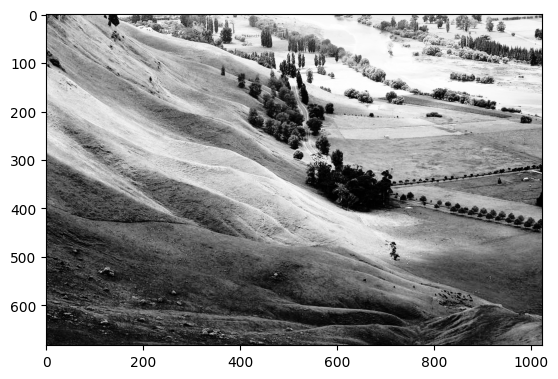

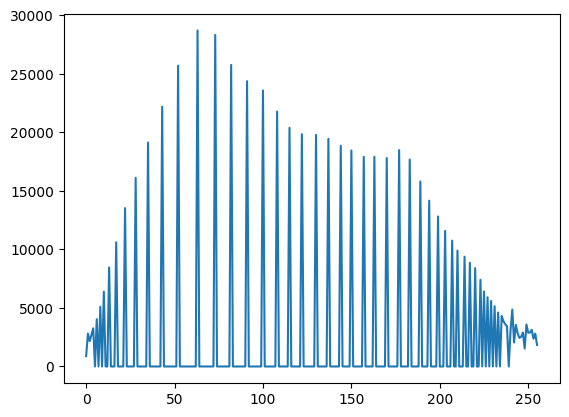

In [10]:
eq_hist = cv2.equalizeHist(img)  # kontrast artırma (0-255 range ini daha iyi kullandık, koyuları 0'a, açıkları 255 e çektik)
plt.figure(), plt.imshow(eq_hist, cmap="gray")
eq_img_hist = cv2.calcHist([eq_hist], channels=[0], mask = None, histSize=[256], ranges=[0, 256])
plt.figure(), plt.plot(eq_img_hist)

In [11]:
# yukarıdaki histogram, kontrastı artırılmış resmin histogramı. bir üstündeki histogram da kontrastı artırılmamış resmin histogramıdır ve baktığın zaman kontrastı artırılmış resim, 0-255 range ini daha iyi kullanmış. bu, resmin daha anlaşılır olmasını sağlıyor